<h1 style="color:#C0392B; font-family:Georgia,serif; text-align:center; padding:20px 0; border-bottom:3px solid #C0392B;">
Text Summarization: Extractive and Abstractive Approaches
</h1>

<p style="text-align:center; font-family:Georgia,serif; font-size:15px; color:#555;">
A structured pipeline combining TF-IDF extractive summarization and BART-based abstractive summarization.
</p>

---
<h2 style="color:#C0392B; font-family:Georgia,serif; background:#fdf2f2; padding:12px 18px; border-left:6px solid #C0392B; border-radius:4px;">
Part 1 — Setup and Preprocessing
</h2>

This section installs all required dependencies, imports libraries, loads the dataset, and applies preprocessing steps necessary for both the TF-IDF and BART pipelines.

<h3 style="color:#C0392B; font-family:Georgia,serif;">1.0 — Dependency Installation</h3>

PyTorch must be installed **before** importing `transformers`. The CPU-only build is used here for compatibility across all environments.

> **Required workflow:** Run this cell once → wait for it to complete → **Kernel → Restart** → then run all remaining cells in order.

In [4]:
# ── Run this cell once, then restart the kernel before running anything else ──
import subprocess, sys

# Step 1: Install CPU-only PyTorch (must come before transformers)
subprocess.check_call([
    sys.executable, "-m", "pip", "install",
    "torch", "torchvision", "torchaudio",
    "--index-url", "https://download.pytorch.org/whl/cpu",
    "--quiet"
])

# Step 2: Install remaining dependencies
subprocess.check_call([
    sys.executable, "-m", "pip", "install",
    "transformers", "scikit-learn", "nltk", "pandas", "numpy",
    "--quiet"
])

print("Installation complete.")
print("ACTION REQUIRED: Go to Kernel > Restart, then run all remaining cells.")

Installation complete.
ACTION REQUIRED: Go to Kernel > Restart, then run all remaining cells.


<h3 style="color:#C0392B; font-family:Georgia,serif;">1.1 — Environment Verification</h3>

Confirm that PyTorch is available before importing the `transformers` library. If this cell raises an error, re-run cell 1.0 and restart the kernel.

In [5]:
try:
    import torch
    print(f"PyTorch version : {torch.__version__}")
    print(f"CUDA available  : {torch.cuda.is_available()}  (False is expected on CPU-only builds)")
except ImportError:
    raise ImportError(
        "PyTorch not found. Run cell 1.0 first, restart the kernel, then re-run from this cell."
    )

PyTorch version : 2.11.0+cpu
CUDA available  : False  (False is expected on CPU-only builds)


<h3 style="color:#C0392B; font-family:Georgia,serif;">1.2 — Imports</h3>

In [6]:
import re
import warnings
import torch
import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import contractions
from tqdm import tqdm
tqdm.pandas()
import textstat
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.tokenize import sent_tokenize
from nltk.corpus import stopwords
from transformers import BartTokenizer, BartForConditionalGeneration

warnings.filterwarnings('ignore')

# Download required NLTK resources if not already present
for pkg, path in [("punkt",     "tokenizers/punkt"),
                  ("punkt_tab", "tokenizers/punkt_tab"),
                  ("stopwords", "corpora/stopwords")]:
    try:
        nltk.data.find(path)
    except LookupError:
        nltk.download(pkg, quiet=True)

STOP_WORDS = set(stopwords.words('english'))
print("All libraries imported successfully.")

C:\Users\Menna\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\Menna\AppData\Roaming\Python\Python312\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


All libraries imported successfully.


<h3 style="color:#C0392B; font-family:Georgia,serif;">1.3 — Data Loading</h3>

Load a sample of 50,000 records to ensure manageable memory usage during development and evaluation.

In [7]:
SAMPLE_SIZE = 50_000
DATA_PATH   = 'data.csv'

raw_df = pd.read_csv(DATA_PATH, nrows=SAMPLE_SIZE)
df     = raw_df[['Content', 'Summary']].copy()

print(f"Loaded  : {len(df):,} records")
print(f"Columns : {df.columns.tolist()}")
df.head(3)

Loaded  : 50,000 records
Columns : ['Content', 'Summary']


,Content,Summary
0,New York police are concerned drones could bec...,Police have investigated criminals who have ri...
1,By . Ryan Lipman . Perhaps Australian porn sta...,Porn star Angela White secretly filmed sex act...
2,"This was, Sergio Garcia conceded, much like be...",American draws inspiration from fellow country...


<h3 style="color:#C0392B; font-family:Georgia,serif;">1.4 — Data Exploration</h3>

In [8]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Content  49997 non-null  str  
 1   Summary  50000 non-null  str  
dtypes: str(2)
memory usage: 208.1 MB


In [9]:
df.describe()
df.isnull().sum()

Content    3
Summary    0
dtype: int64

In [10]:
df.duplicated().sum()
df = df[['Content','Summary']]
df = df.dropna()
df.shape

(49997, 2)

<h3 style="color:#C0392B; font-family:Georgia,serif;">1.5 — Exploratory Data Analysis (EDA)</h3>

In [11]:
df['Content_len'] = df.Content.apply(len)
df.Content_len.describe()

count     49997.000000
mean       4016.499250
std        4337.104613
min          25.000000
25%        2053.000000
50%        3325.000000
75%        4973.000000
max      330704.000000
Name: Content_len, dtype: float64

In [12]:
df['Summary_len'] = df.Summary.apply(len)
df.Summary_len.describe()

count    49997.000000
mean       316.850691
std        307.864152
min          1.000000
25%        148.000000
50%        243.000000
75%        336.000000
max       6959.000000
Name: Summary_len, dtype: float64

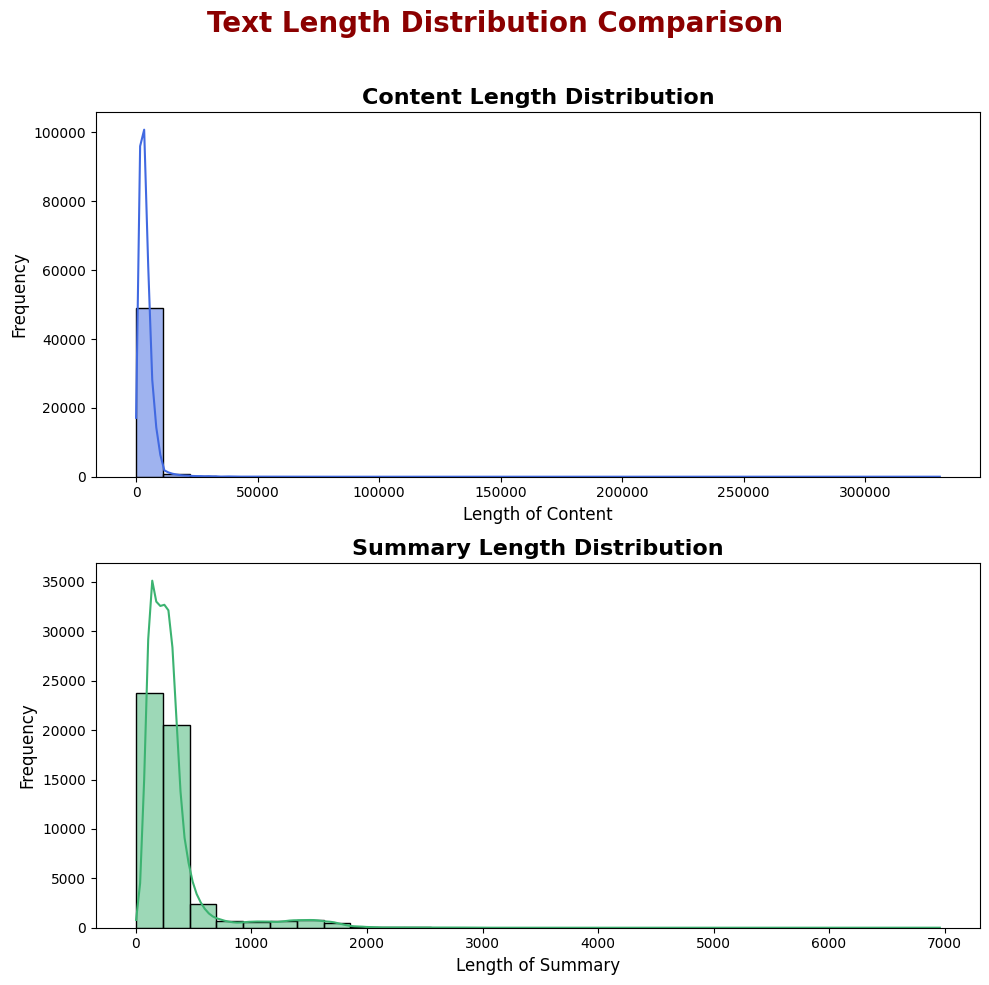

In [13]:
plt.figure(figsize=(10,10))

# Plot for News Length
plt.subplot(2, 1, 1)
sns.histplot(df['Content_len'], kde=True, color='royalblue', bins=30)
plt.title('Content Length Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Length of Content', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Plot for Summary Length
plt.subplot(2, 1, 2)
sns.histplot(df['Summary_len'], kde=True, color='mediumseagreen', bins=30)
plt.title('Summary Length Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Length of Summary', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.suptitle('Text Length Distribution Comparison', fontsize=20, fontweight='bold', color='darkred')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

100%|██████████| 49997/49997 [00:08<00:00, 5866.86it/s]


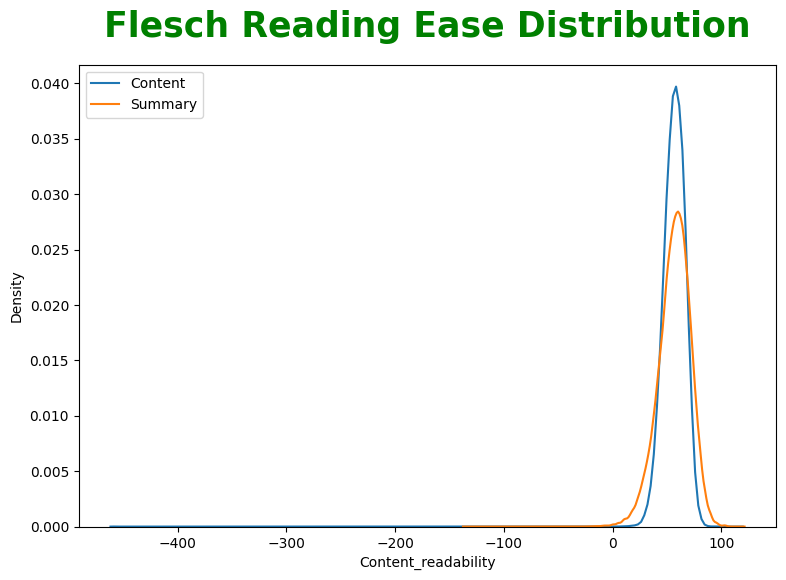

In [14]:
flesch_reading_ease = textstat.flesch_reading_ease   
df['Content_readability'] = df['Content'].progress_apply(flesch_reading_ease)
df['Summary_readability'] = df['Summary'].progress_apply(flesch_reading_ease)


plt.figure(figsize=(9,6))
sns.kdeplot(df['Content_readability'], label='Content')
sns.kdeplot(df['Summary_readability'], label='Summary')
plt.title("Flesch Reading Ease Distribution",fontsize=25,pad=20,color='green',fontweight='bold')
plt.legend()
plt.show();

100%|██████████| 49997/49997 [00:06<00:00, 7805.06it/s] 


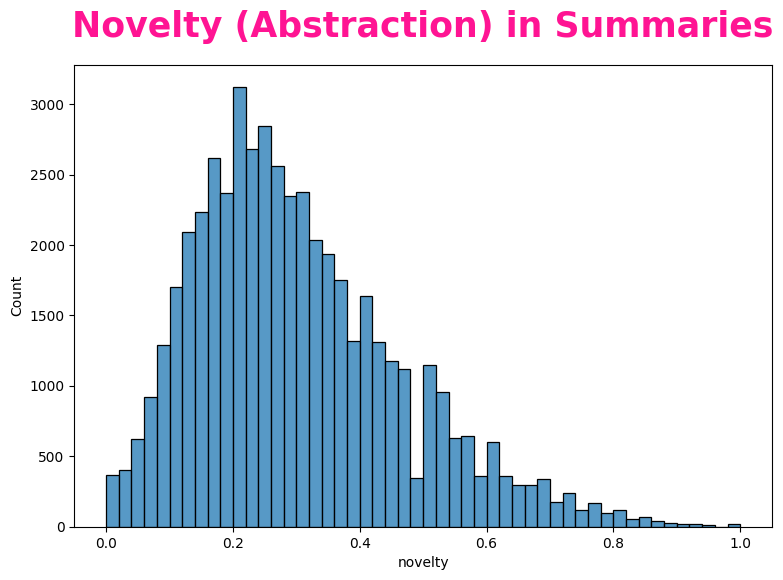

In [15]:
def novelty_ratio(content, Summary):
    d = set(content.split())
    s = set(Summary.split())
    return len(s - d) / max(1, len(s))


df['novelty'] = df.progress_apply(lambda x: novelty_ratio(x['Content'], x['Summary']), axis=1)

plt.figure(figsize=(9,6))
sns.histplot(df['novelty'], bins=50, palette='coolwarm')
plt.title("Novelty (Abstraction) in Summaries",fontsize=25,pad=20,color='deeppink',fontweight='bold')
plt.show();

<h3 style="color:#C0392B; font-family:Georgia,serif;">1.6 — Data Cleaning</h3>

Remove null values, duplicate rows, and samples below the minimum length threshold.

In [16]:
MIN_CONTENT_LENGTH = 100
initial_size       = len(df)

df.dropna(subset=['Content', 'Summary'], inplace=True)
df.drop_duplicates(subset=['Content'], inplace=True)
df = df[df['Content'].str.len() >= MIN_CONTENT_LENGTH]
df.reset_index(drop=True, inplace=True)

print(f"Removed  : {initial_size - len(df):,} invalid records")
print(f"Retained : {len(df):,} clean records")

Removed  : 1,067 invalid records
Retained : 48,930 clean records


<h3 style="color:#C0392B; font-family:Georgia,serif;">1.7 — Text Preprocessing</h3>

Normalize the `Content` column for TF-IDF processing. The original `Content` is preserved separately — BART performs best on unmodified natural-language text.

In [17]:
def clean_text(text: str) -> str:
    """Normalize text for TF-IDF processing."""
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)   # remove URLs
    text = re.sub(r'[^a-z\s]', '', text)            # remove punctuation and digits
    text = re.sub(r'\s+', ' ', text).strip()        # collapse whitespace
    return text


df['Content_Clean'] = df['Content'].apply(clean_text)

print("Original :", df['Content'].iloc[0][:120])
print("Cleaned  :", df['Content_Clean'].iloc[0][:120])

Original : New York police are concerned drones could become tools for terrorists, and are investigating ways to stop potential att
Cleaned  : new york police are concerned drones could become tools for terrorists and are investigating ways to stop potential atta


In [18]:
def remove_emoji(text):
    emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)

In [19]:
def expand_contractions(text):
    return contractions.fix(text)

In [20]:
df.Content = df.Content.progress_apply(clean_text)
df.Content = df.Content.progress_apply(remove_emoji)
df.Content = df.Content.progress_apply(expand_contractions)

100%|██████████| 48930/48930 [00:11<00:00, 4433.12it/s]


In [21]:
df.Summary = df.Summary.progress_apply(clean_text)
df.Summary = df.Summary.progress_apply(remove_emoji)
df.Summary = df.Summary.progress_apply(expand_contractions)

100%|██████████| 48930/48930 [00:00<00:00, 59911.44it/s]


<h3 style="color:#C0392B; font-family:Georgia,serif;">1.8 — Train / Test Split</h3>

Partition into training (80%) and test (20%) subsets with a fixed random seed for reproducibility.

In [22]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)

print(f"Training samples : {len(train_df):,}")
print(f"Test samples     : {len(test_df):,}")

Training samples : 39,144
Test samples     : 9,786


---
<h2 style="color:#C0392B; font-family:Georgia,serif; background:#fdf2f2; padding:12px 18px; border-left:6px solid #C0392B; border-radius:4px;">
Part 2 — TF-IDF Extractive Summarization
</h2>

Extractive summarization selects the most informative sentences from the source document. Sentence importance is scored using TF-IDF weights and the top-N sentences are returned in original document order to preserve coherence.

In [23]:
def tfidf_summary(text: str, n_sentences: int = 3) -> str:
    """
    Generate an extractive summary using TF-IDF sentence ranking.

    Parameters
    ----------
    text        : str  — Input document text.
    n_sentences : int  — Number of top sentences to include.

    Returns
    -------
    str — Extracted summary in original sentence order.
    """
    sentences = sent_tokenize(text)

    if len(sentences) <= n_sentences:
        return text

    vectorizer      = TfidfVectorizer(stop_words='english')
    tfidf_matrix    = vectorizer.fit_transform(sentences)
    sentence_scores = np.array(tfidf_matrix.mean(axis=1)).flatten()
    top_indices     = sorted(np.argsort(sentence_scores)[-n_sentences:])

    return ' '.join([sentences[i] for i in top_indices])

In [24]:
# Demonstrate on one test sample
sample_text  = test_df['Content'].iloc[0]
tfidf_result = tfidf_summary(sample_text, n_sentences=3)

print("=== Original Text (first 400 chars) ===")
print(sample_text[:400])
print()
print("=== TF-IDF Extractive Summary ===")
print(tfidf_result)

=== Original Text (first 400 chars) ===
after a raindelayed start an inningsbest partnership of between will smith and gareth berg carried the hosts score past neil dexter claimed four of the five wickets to fall in the day with his medium pace to achieve figures of joe burns edged the penultimate ball of the day behind to leave middlesex still runs behind rain meant that play got under way at bst and hampshire lost sean ervine early on

=== TF-IDF Extractive Summary ===
after a raindelayed start an inningsbest partnership of between will smith and gareth berg carried the hosts score past neil dexter claimed four of the five wickets to fall in the day with his medium pace to achieve figures of joe burns edged the penultimate ball of the day behind to leave middlesex still runs behind rain meant that play got under way at bst and hampshire lost sean ervine early on when he was bowled by toby rolandjones after adding just one run that brought gareth berg to the crease and the former midd

In [25]:
# Apply TF-IDF summarization across the full test set
test_df['TF-IDF_Summary'] = test_df['Content'].apply(
    lambda x: tfidf_summary(x, n_sentences=3)
)
print(f"TF-IDF summaries generated for {len(test_df):,} test samples.")

TF-IDF summaries generated for 9,786 test samples.


---
<h2 style="color:#C0392B; font-family:Georgia,serif; background:#fdf2f2; padding:12px 18px; border-left:6px solid #C0392B; border-radius:4px;">
Part 3 — BART Abstractive Summarization
</h2>

Abstractive summarization generates novel text that captures the essence of the source document. The `facebook/bart-large-cnn` model is used — a transformer fine-tuned specifically on news summarization. Raw unmodified text is passed as input, as the model was trained on natural-language prose.

In [26]:
BART_MODEL_NAME = 'facebook/bart-large-cnn'

print(f"Loading model: {BART_MODEL_NAME} ...")
bart_tokenizer = BartTokenizer.from_pretrained(BART_MODEL_NAME)
bart_model     = BartForConditionalGeneration.from_pretrained(BART_MODEL_NAME)
bart_model.eval()   # disable dropout for deterministic inference
print("Model loaded successfully.")

Loading model: facebook/bart-large-cnn ...


[transformers] Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

Model loaded successfully.


In [27]:
def bart_summary(
    text: str,
    max_input_length:  int = 1024,
    max_output_length: int = 150,
    min_output_length: int = 40,
    num_beams:         int = 4
) -> str:
    """
    Generate an abstractive summary using the BART-large-CNN model.

    Parameters
    ----------
    text              : str — Input document (unmodified natural language).
    max_input_length  : int — Maximum encoder token length.
    max_output_length : int — Maximum tokens in the generated summary.
    min_output_length : int — Minimum tokens in the generated summary.
    num_beams         : int — Beam search width.

    Returns
    -------
    str — Abstractive summary produced by BART.
    """
    inputs = bart_tokenizer(
        text,
        return_tensors='pt',
        max_length=max_input_length,
        truncation=True
    )

    with torch.no_grad():   # disable gradient tracking for inference efficiency
        summary_ids = bart_model.generate(
            inputs['input_ids'],
            max_length=max_output_length,
            min_length=min_output_length,
            num_beams=num_beams,
            length_penalty=2.0,
            early_stopping=True
        )

    return bart_tokenizer.decode(summary_ids[0], skip_special_tokens=True)

In [28]:
# Demonstrate on one test sample
bart_result = bart_summary(sample_text)

print("=== Original Text (first 400 chars) ===")
print(sample_text[:400])
print()
print("=== BART Abstractive Summary ===")
print(bart_result)

=== Original Text (first 400 chars) ===
after a raindelayed start an inningsbest partnership of between will smith and gareth berg carried the hosts score past neil dexter claimed four of the five wickets to fall in the day with his medium pace to achieve figures of joe burns edged the penultimate ball of the day behind to leave middlesex still runs behind rain meant that play got under way at bst and hampshire lost sean ervine early on

=== BART Abstractive Summary ===
after a raindelayed start an inningsbest partnership of between will smith and gareth berg carried the hosts score past neil dexter claimed four of the five wickets to fall in the day with his medium pace. joe burns edged the penultimate ball of the day behind to leave middlesex still runs behind rain.


In [29]:
# Apply BART to a limited evaluation subset (constrained by CPU inference time)
EVAL_SAMPLE_SIZE        = 100
eval_df                 = test_df.head(EVAL_SAMPLE_SIZE).copy()
eval_df['BART_Summary'] = eval_df['Content'].apply(bart_summary)

print(f"BART summaries generated for {EVAL_SAMPLE_SIZE} evaluation samples.")

BART summaries generated for 100 evaluation samples.


---
<h2 style="color:#C0392B; font-family:Georgia,serif; background:#fdf2f2; padding:12px 18px; border-left:6px solid #C0392B; border-radius:4px;">
Part 4 — Pipeline Integration
</h2>

A unified `summarize_text` function wraps both approaches behind a single interface. The caller selects the desired method via the `method` parameter, enabling seamless switching between extractive and abstractive modes.

In [30]:
def summarize_text(text: str, method: str = 'bart') -> str:
    """
    Unified summarization interface.

    Parameters
    ----------
    text   : str — Input document text.
    method : str — 'tfidf' for extractive, 'bart' for abstractive.

    Returns
    -------
    str — Generated summary.

    Raises
    ------
    ValueError — If input is empty or method is unsupported.
    """
    if not isinstance(text, str) or not text.strip():
        raise ValueError("Input text must be a non-empty string.")

    method = method.lower().strip()

    if method == 'tfidf':
        return tfidf_summary(text, n_sentences=3)
    elif method == 'bart':
        return bart_summary(text)
    else:
        raise ValueError(f"Unknown method '{method}'. Choose 'tfidf' or 'bart'.")

In [31]:
# Validate both methods through the unified pipeline
test_input = test_df['Content'].iloc[1]

print(" Original Text: ")
print(test_input)

print()
print(" TF-IDF via Pipeline:")
print(summarize_text(test_input, method='tfidf'))

print()
print(" BART via Pipeline:")
print(summarize_text(test_input, method='bart'))

 Original Text: 
by sam webb for mailonline a man who paid a drug addict just to kill his wife because he was having an affair with her sister was convicted has been convicted of murder motheroftwo amina bibi was stabbed at least times in the attack at the couples flat in forest gate east london her yearold son found her dying in a pool of blood when he returned to his home after forgetting his homework on the morning of friday september husband mohamed ali was heavily in debt and having an affair with his sisterinlaw in pakistan when he approached drug addict frederick best scroll down for video motheroftwo amina bibi was stabbed at least times by an addict paid by her husband mohamed ali right mrs bibi had savings in the house and officers believe the debt and his affair could have been a motive mrs bibi had significant savings in the house and officers believe the debt and affair could have been a motive for ali to have his wife murdered ali did the school run to give himself an ali

---
<h2 style="color:#C0392B; font-family:Georgia,serif; background:#fdf2f2; padding:12px 18px; border-left:6px solid #C0392B; border-radius:4px;">
Part 5 — ROUGE Evaluation
</h2>

ROUGE (Recall-Oriented Understudy for Gisting Evaluation) measures overlap between generated and reference summaries using F1 scores.
Three variants are computed:
- **ROUGE-1** — Unigram overlap
- **ROUGE-2** — Bigram overlap  
- **ROUGE-L** — Longest common subsequence

Evaluation is performed on the same 100-sample `eval_df` subset used for BART inference.

In [32]:
!pip install rouge-score --quiet
print("rouge-score ready.")

rouge-score ready.


In [33]:
from rouge_score import rouge_scorer

def compute_avg_rouge(generated_summaries: list, reference_summaries: list) -> dict:
    """
    Compute average ROUGE-1, ROUGE-2, and ROUGE-L F1 scores.

    Parameters
    ----------
    generated_summaries : list[str] — Summaries produced by the model.
    reference_summaries : list[str] — Human-written reference summaries.

    Returns
    -------
    dict — Average F1 scores for rouge1, rouge2, rougeL.
    """
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    totals = {'rouge1': 0.0, 'rouge2': 0.0, 'rougeL': 0.0}
    n      = len(generated_summaries)

    for gen, ref in zip(generated_summaries, reference_summaries):
        scores = scorer.score(ref, gen)
        for key in totals:
            totals[key] += scores[key].fmeasure

    return {key: round(val / n, 4) for key, val in totals.items()}

In [34]:
# Generate TF-IDF summaries for the same eval_df subset
eval_df['TF-IDF_Summary'] = eval_df['Content'].apply(
    lambda x: tfidf_summary(x, n_sentences=3)
)
print(f"TF-IDF summaries generated for {len(eval_df):,} evaluation samples.")

TF-IDF summaries generated for 100 evaluation samples.


In [35]:
# Compute ROUGE scores for both models
references   = eval_df['Summary'].tolist()
tfidf_scores = compute_avg_rouge(eval_df['TF-IDF_Summary'].tolist(), references)
bart_scores  = compute_avg_rouge(eval_df['BART_Summary'].tolist(),   references)

print('ROUGE Scores (F1 — higher is better)\n')
print(f"{'Metric':<12} {'TF-IDF':>10} {'BART':>10}")
print('-' * 34)
for metric in ['rouge1', 'rouge2', 'rougeL']:
    print(f"{metric:<12} {tfidf_scores[metric]:>10.4f} {bart_scores[metric]:>10.4f}")

ROUGE Scores (F1 — higher is better)

Metric           TF-IDF       BART
----------------------------------
rouge1           0.1353     0.3353
rouge2           0.0613     0.1342
rougeL           0.0952     0.2306


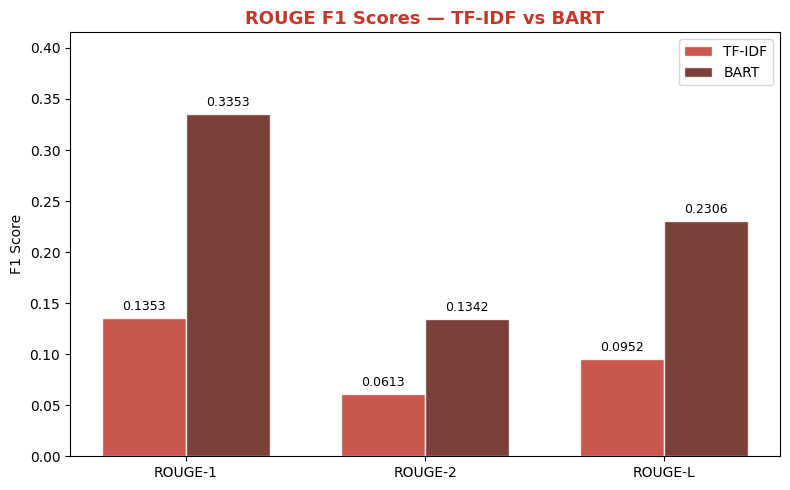

In [36]:
# ── ROUGE Bar Chart — TF-IDF vs BART ──────────────────────────────────────────────
metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
keys    = ['rouge1', 'rouge2', 'rougeL']
x       = np.arange(len(metrics))
width   = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(x - width/2, [tfidf_scores[k] for k in keys], width,
               label='TF-IDF', color='#C0392B', edgecolor='white', alpha=0.85)
bars2 = ax.bar(x + width/2, [bart_scores[k]  for k in keys], width,
               label='BART',   color='#641E16', edgecolor='white', alpha=0.85)

ax.set_title('ROUGE F1 Scores — TF-IDF vs BART', fontsize=13, color='#C0392B', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('F1 Score')
ax.set_ylim(0, max(max(tfidf_scores.values()), max(bart_scores.values())) + 0.08)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()